Multi-Scale Semantic Tagging for Lyrics-Based Music Structure Analysis Using Lightweight Bidirectional Long Short-Term Memory

1.Proposed Bi-LSTM (Record 10 times of best parameters)  
2.Proposed Bi-LSTM (Re-produce seed=43)  
3.Proposed Bi-LSTM (Ablation Test)  
4.Baseline--SongFormer (seed=43)  
5.Baseline--LongFormer (seed=43)  
6.Proposed Bi-LSTM (Final Modified, seed=43)  

1.Proposed Bi-LSTM (Record 10 times of best parameters)

In [ ]:
# ==========================================
# Optimized Bi-LSTM
# ==========================================

import os
import random
import time
import glob
import psutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, Subset
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel

from google.colab import drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# ============================================================
# Dataset Path
# ============================================================
# Please set this path to the location of your reconstructed
# dataset in your own Google Drive.
#
# DATA_DIR = "/content/drive/MyDrive/YOUR_DATASET_FOLDER"

DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/2025~2026_RY_Thesis/2025.1221_Processed_148_Common_Lyrics/148_Aligned_Paragraph_Structure_Delete_Different"
ULTIMATE_MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/2025~2026_RY_Thesis/ultimate_encoder_model"
SAVE_PATH = "/content/drive/MyDrive/Colab Notebooks/2025~2026_RY_Thesis/best_model_run_config.pt"

MAX_LEN = 256
TARGET_LABELS = ['Verse', 'Pre-Chorus', 'Chorus', 'Intro', 'Outro', 'Bridge', 'Instruments']
NUM_RUNS = 10
device = 'cuda' if torch.cuda.is_available() else 'cpu'

label_encoder = LabelEncoder()
label_encoder.fit(TARGET_LABELS)
inst_idx = label_encoder.transform(['Instruments'])[0]

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ==========================================
# 3. Function and Model
# ==========================================
class SystemMonitor:
    def __init__(self):
        self.process = psutil.Process(os.getpid())
    def start(self):
        self.start_time = time.time()
        if torch.cuda.is_available(): torch.cuda.reset_peak_memory_stats()
    def stop(self):
        self.end_time = time.time()
        self.max_gpu_mem = torch.cuda.max_memory_allocated() / (1024**2) if torch.cuda.is_available() else 0
    def get_duration(self): return self.end_time - self.start_time
    def get_ram_usage(self): return self.process.memory_info().rss / (1024**2)

class OptimizedBiLSTM_Dynamic(nn.Module):
    def __init__(self, input_dim, n_classes):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=256, num_layers=2, batch_first=True, bidirectional=True, dropout=0.1)
        self.clf = nn.Sequential(nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.1), nn.Linear(256, n_classes))
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.clf(out.squeeze(0))

class AblationDataset(Dataset):
    def __init__(self, cache_list): self.data = cache_list
    def __len__(self): return len(self.data)
    def __getitem__(self, i):
        d = self.data[i]
        x = torch.cat([d['w_emb'], d['s_emb'], d['pos'].unsqueeze(1), d['rep']], dim=1)
        return x, d['labels']

def get_metrics(y_true, y_pred, window=0):
    hits = 0
    for i in range(len(y_true)):
        start, end = max(0, i - window), min(len(y_true), i + window + 1)
        if y_true[i] in y_pred[start:end]: hits += 1
    return hits / len(y_true) if len(y_true) > 0 else 0

def compute_cached_features(lyrics_list, section_texts, tokenizer, model, device):
    w_embs, batch_size = [], 32
    lines = [f"{' '.join(lyrics_list[max(0,i-2):i])} {tokenizer.sep_token} {lyrics_list[i]} {tokenizer.sep_token} {' '.join(lyrics_list[i+1:min(len(lyrics_list),i+3)])}" for i in range(len(lyrics_list))]
    with torch.no_grad():
        for i in range(0, len(lines), batch_size):
            batch = lines[i:i+batch_size]
            inp = tokenizer(batch, padding=True, truncation=True, max_length=MAX_LEN, return_tensors='pt').to(device)
            out = model(**inp).last_hidden_state
            mask = inp['attention_mask']
            emb = (out * mask.unsqueeze(-1)).sum(1) / mask.sum(1, keepdim=True).clamp(min=1e-9)
            w_embs.append(emb.cpu())
    w_tensor = torch.cat(w_embs, dim=0)

    unique_secs = list(set(section_texts))
    sec_map = {}
    with torch.no_grad():
        for i in range(0, len(unique_secs), batch_size):
            batch = unique_secs[i:i+batch_size]
            inp = tokenizer(batch, padding=True, truncation=True, max_length=MAX_LEN, return_tensors='pt').to(device)
            out = model(**inp).last_hidden_state
            mask = inp['attention_mask']
            emb = (out * mask.unsqueeze(-1)).sum(1) / mask.sum(1, keepdim=True).clamp(min=1e-9)
            res = emb.cpu()
            for j, txt in enumerate(batch): sec_map[txt] = res[j]
    s_tensor = torch.stack([sec_map[t] for t in section_texts])
    sim_matrix = cosine_similarity(w_tensor.numpy())
    rep_feats = []
    for i in range(len(lyrics_list)):
        sims = sim_matrix[i].copy(); sims[i] = -1.0
        rep_feats.append([sims.max(), float(sims.max() > 0.85), float((sims > 0.8).sum())])
    return w_tensor, s_tensor, torch.tensor(rep_feats, dtype=torch.float)

print("🚀 正在初始化 Encoder 並預計算特徵...")
try:
    feat_tokenizer = AutoTokenizer.from_pretrained(ULTIMATE_MODEL_PATH)
    feat_model = AutoModel.from_pretrained(ULTIMATE_MODEL_PATH).to(device).eval()
except:
    print("⚠️ 找不到 Ultimate Model，降級使用 roberta-base")
    feat_tokenizer = AutoTokenizer.from_pretrained("roberta-base")
    feat_model = AutoModel.from_pretrained("roberta-base").to(device).eval()

csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
data_cache = []

for f in tqdm(csv_files, desc="Pre-computing features"):
    try:
        df = pd.read_csv(f).dropna(subset=['lyrics', 'harmonix_section'])
        df = df[df['harmonix_section'].isin(TARGET_LABELS)].reset_index(drop=True)
        if len(df) == 0: continue

        df['group_id'] = (df['harmonix_section'] != df['harmonix_section'].shift()).cumsum()
        total_sections = df['group_id'].nunique()
        section_texts, rel_positions = [""] * len(df), [0.0] * len(df)
        group_rank_map = {gid: i for i, gid in enumerate(sorted(df['group_id'].unique()))}
        for gid, group in df.groupby('group_id'):
            full_txt = " ".join(group['lyrics'].astype(str).tolist())
            pos = group_rank_map[gid] / (total_sections - 1) if total_sections > 1 else 0.0
            for idx in group.index: section_texts[idx] = full_txt; rel_positions[idx] = pos

        w_t, s_t, r_t = compute_cached_features(df['lyrics'].astype(str).tolist(), section_texts, feat_tokenizer, feat_model, device)
        data_cache.append({'w_emb': w_t, 's_emb': s_t, 'rep': r_t, 'pos': torch.tensor(rel_positions, dtype=torch.float), 'labels': torch.tensor(label_encoder.transform(df['harmonix_section']), dtype=torch.long)})
    except Exception as e: continue

del feat_model, feat_tokenizer
torch.cuda.empty_cache()

# ==========================================
# 5. Execute 10 times of 5-Fold Experiments
# ==========================================
best_overall_wf1 = -1.0
best_run_data = {}
eval_names = [n for n in label_encoder.classes_ if n != 'Instruments']

print(f"\n🔥 開始執行 {NUM_RUNS} 次重複實驗...")

for run_idx in range(NUM_RUNS):
    current_seed = 42 + run_idx
    set_seed(current_seed)
    print(f"\n▶️ [Run {run_idx+1}/{NUM_RUNS}] 使用種子: {current_seed}")

    kf = KFold(n_splits=5, shuffle=True, random_state=current_seed)
    results_per_fold = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(data_cache)):
        train_ds = Subset(AblationDataset(data_cache), train_idx)
        val_ds = Subset(AblationDataset(data_cache), val_idx)

        model = OptimizedBiLSTM_Dynamic(1540, len(label_encoder.classes_)).to(device)
        optimizer = AdamW(model.parameters(), lr=1.8e-4, weight_decay=1e-3)
        criterion = nn.CrossEntropyLoss()

        # Training (15 Epochs)
        model.train()
        for epoch in range(15):
            for x, y in train_ds:
                optimizer.zero_grad()
                out = model(x.unsqueeze(0).to(device))
                loss = criterion(out, y.to(device))
                loss.backward()
                optimizer.step()

        # Validation
        model.eval()
        y_true_fold, y_pred_fold = [], []
        with torch.no_grad():
            for x, y in val_ds:
                out = model(x.unsqueeze(0).to(device))
                y_pred_fold.extend(torch.argmax(out, dim=1).cpu().tolist())
                y_true_fold.extend(y.tolist())

        clean_true = [t for t, p in zip(y_true_fold, y_pred_fold) if t != inst_idx]
        clean_pred = [p for t, p in zip(y_true_fold, y_pred_fold) if t != inst_idx]

        report = classification_report(clean_true, clean_pred, target_names=eval_names, output_dict=True, zero_division=0)

        results_per_fold.append({
            'wf1': precision_recall_fscore_support(clean_true, clean_pred, average='weighted', zero_division=0)[2],
            'h05': get_metrics(clean_true, clean_pred, 0),
            'l_measure': accuracy_score(clean_true, clean_pred),
            'report': report
        })
        del model; torch.cuda.empty_cache()

    run_metrics = {}
    for label in eval_names:
        f1_list = []
        for r in results_per_fold:
            f1 = r['report'].get(label, {}).get('f1-score', 0)
            # 核心邏輯：如果 Outro 的 F1 為 0，則排除該 fold 數據
            if label == 'Outro' and f1 == 0: continue
            f1_list.append(f1)

        if f1_list:
            run_metrics[label] = {'mean': np.mean(f1_list), 'std': np.std(f1_list)}
        else:
            run_metrics[label] = {'mean': 0.0, 'std': 0.0}

    current_avg_wf1 = np.mean([r['wf1'] for r in results_per_fold])
    current_std_wf1 = np.std([r['wf1'] for r in results_per_fold])

    print(f"📊 Run {run_idx+1} Avg WF1: {current_avg_wf1:.4f} (±{current_std_wf1:.4f})")

    if current_avg_wf1 > best_overall_wf1:
        best_overall_wf1 = current_avg_wf1
        best_run_data = {
            'seed': current_seed,
            'avg_wf1': current_avg_wf1,
            'std_wf1': current_std_wf1,
            'paragraph_metrics': run_metrics,
            'avg_h05': np.mean([r['h05'] for r in results_per_fold]),
            'avg_l': np.mean([r['l_measure'] for r in results_per_fold])
        }
        torch.save(best_run_data, SAVE_PATH)

# ==========================================
# 6. Print
# ==========================================
print("\n" + "⭐" * 50)
print("🏆 最佳執行結果彙整 (Best Run Summary)")
print(f"使用的隨機種子 (Random Seed): {best_run_data['seed']}")
print(f"整體 Weighted F1: {best_run_data['avg_wf1']:.4f} ± {best_run_data['std_wf1']:.4f}")
print(f"整體 Hit@0.5s: {best_run_data['avg_h05']:.4f}")
print(f"整體 L-Measure: {best_run_data['avg_l']:.4f}")
print("-" * 50)
print(f"{'段落名稱 (Section)':<15} | {'平均 F1 (Mean)':<12} | {'標準差 (Std)':<10}")
for label, m in best_run_data['paragraph_metrics'].items():
    print(f"{label:<15} | {m['mean']:<12.4f} | {m['std']:<10.4f}")
print("⭐" * 50)
print(f"最佳運行參數已儲存至: {SAVE_PATH}")

Mounted at /content/drive
🚀 正在初始化 Encoder 並預計算特徵...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Pre-computing features:   0%|          | 0/148 [00:00<?, ?it/s]


🔥 開始執行 10 次重複實驗...

▶️ [Run 1/10] 使用種子: 42
📊 Run 1 Avg WF1: 0.7789 (±0.0392)

▶️ [Run 2/10] 使用種子: 43
📊 Run 2 Avg WF1: 0.7848 (±0.0178)

▶️ [Run 3/10] 使用種子: 44
📊 Run 3 Avg WF1: 0.7765 (±0.0397)

▶️ [Run 4/10] 使用種子: 45
📊 Run 4 Avg WF1: 0.7780 (±0.0198)

▶️ [Run 5/10] 使用種子: 46
📊 Run 5 Avg WF1: 0.7673 (±0.0443)

▶️ [Run 6/10] 使用種子: 47
📊 Run 6 Avg WF1: 0.7786 (±0.0464)

▶️ [Run 7/10] 使用種子: 48
📊 Run 7 Avg WF1: 0.7743 (±0.0369)

▶️ [Run 8/10] 使用種子: 49
📊 Run 8 Avg WF1: 0.7889 (±0.0351)

▶️ [Run 9/10] 使用種子: 50
📊 Run 9 Avg WF1: 0.7864 (±0.0423)

▶️ [Run 10/10] 使用種子: 51
📊 Run 10 Avg WF1: 0.7864 (±0.0343)

⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐⭐
🏆 最佳執行結果彙整 (Best Run Summary)
使用的隨機種子 (Random Seed): 49
整體 Weighted F1: 0.7889 ± 0.0351
整體 Hit@0.5s: 0.7908
整體 L-Measure: 0.7908
--------------------------------------------------
段落名稱 (Section)  | 平均 F1 (Mean) | 標準差 (Std) 
Bridge          | 0.5809       | 0.1099    
Chorus          | 0.8728       | 0.0202    
Intro           | 0.5933       | 0

2.Proposed Bi-LSTM (復現並儲存 Seed = 43 的完整結果)

In [ ]:
# ==========================================
# Re-Produce Seed = 43
# ==========================================
import os
import copy
import json
import torch
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support
from tqdm.auto import tqdm

TARGET_SEED = 43
SAVE_DIR_43 = "/content/drive/MyDrive/Colab Notebooks/2025~2026_RY_Thesis/Model_Pack_Seed43"
os.makedirs(SAVE_DIR_43, exist_ok=True)

set_seed(TARGET_SEED)

target_run_results = []
temp_fold_models = []
eval_names = [n for n in label_encoder.classes_ if n != 'Instruments']

print(f"🚀 開始執行 Seed {TARGET_SEED} 的 5-Fold 驗證...")

kf_target = KFold(n_splits=5, shuffle=True, random_state=TARGET_SEED)

for fold, (train_idx, val_idx) in enumerate(kf_target.split(data_cache)):
    print(f"🌀 Processing Fold {fold+1}/5...")

    # Split data
    train_ds = Subset(AblationDataset(data_cache), train_idx)
    val_ds = Subset(AblationDataset(data_cache), val_idx)

    # Initialize model
    model = OptimizedBiLSTM_Dynamic(1540, len(label_encoder.classes_)).to(device)
    optimizer = AdamW(model.parameters(), lr=1.8e-4, weight_decay=1e-3)
    criterion = nn.CrossEntropyLoss()

    # Training (15 Epochs)
    model.train()
    for epoch in range(15):
        for x, y in train_ds:
            optimizer.zero_grad()
            out = model(x.unsqueeze(0).to(device))
            loss = criterion(out, y.to(device))
            loss.backward()
            optimizer.step()

    temp_fold_models.append(copy.deepcopy(model.state_dict()))

    # Evaluate
    model.eval()
    y_true_fold, y_pred_fold = [], []
    with torch.no_grad():
        for x, y in val_ds:
            out = model(x.unsqueeze(0).to(device))
            y_pred_fold.extend(torch.argmax(out, dim=1).cpu().tolist())
            y_true_fold.extend(y.tolist())

    clean_true = [t for t, p in zip(y_true_fold, y_pred_fold) if t != inst_idx]
    clean_pred = [p for t, p in zip(y_true_fold, y_pred_fold) if t != inst_idx]

    report = classification_report(clean_true, clean_pred, target_names=eval_names, output_dict=True, zero_division=0)

    wf1 = precision_recall_fscore_support(clean_true, clean_pred, average='weighted', zero_division=0)[2]
    h05 = get_metrics(clean_true, clean_pred, 0)
    l_measure = accuracy_score(clean_true, clean_pred)

    target_run_results.append({
        'wf1': wf1,
        'h05': h05,
        'l_measure': l_measure,
        'report': report
    })

    print(f"   Fold {fold+1} WF1: {wf1:.4f}")
    del model; torch.cuda.empty_cache()

final_metrics_43 = {}
for label in eval_names:
    f1_list = [r['report'].get(label, {}).get('f1-score', 0) for r in target_run_results]

    if label == 'Outro':
        original_len = len(f1_list)
        f1_list = [f1 for f1 in f1_list if f1 != 0]
        if len(f1_list) < original_len:
            print(f"⚠️ 偵測到 Outro F1=0，已過濾該 Fold，計算樣本數從 {original_len} 降至 {len(f1_list)}")

    final_metrics_43[label] = {
        'mean': round(np.mean(f1_list), 4) if f1_list else 0.0,
        'std': round(np.std(f1_list), 4) if f1_list else 0.0
    }

# Saving
print(f"\n💾 正在儲存 Seed {TARGET_SEED} 完整數據至 Google Drive...")

torch.save(temp_fold_models[-1], os.path.join(SAVE_DIR_43, f"model_weights_seed{TARGET_SEED}.pth"))

torch.save(label_encoder, os.path.join(SAVE_DIR_43, "label_encoder.pt"))

avg_wf1 = np.mean([r['wf1'] for r in target_run_results])
std_wf1 = np.std([r['wf1'] for r in target_run_results])

summary_data = {
    'seed': TARGET_SEED,
    'overall_avg_wf1': round(avg_wf1, 4),
    'overall_std_wf1': round(std_wf1, 4),
    'overall_avg_h05': round(np.mean([r['h05'] for r in target_run_results]), 4),
    'overall_avg_l_measure': round(np.mean([r['l_measure'] for r in target_run_results]), 4),
    'paragraph_detailed_metrics': final_metrics_43,
    'timestamp': time.strftime("%Y-%m-%d %H:%M:%S")
}

torch.save(summary_data, os.path.join(SAVE_DIR_43, f"metrics_seed{TARGET_SEED}.pt"))

with open(os.path.join(SAVE_DIR_43, f"report_seed{TARGET_SEED}.json"), "w", encoding="utf-8") as f:
    json.dump(summary_data, f, indent=4, ensure_ascii=False)

print("-" * 50)
print(f"🎉 Seed {TARGET_SEED} 執行完畢！")
print(f"📊 平均 Weighted F1: {avg_wf1:.4f} (±{std_wf1:.4f})")
print(f"📂 儲存目錄: {SAVE_DIR_43}")

🚀 開始執行 Seed 43 的 5-Fold 驗證...
🌀 Processing Fold 1/5...
   Fold 1 WF1: 0.7770
🌀 Processing Fold 2/5...
   Fold 2 WF1: 0.8037
🌀 Processing Fold 3/5...
   Fold 3 WF1: 0.8082
🌀 Processing Fold 4/5...
   Fold 4 WF1: 0.7645
🌀 Processing Fold 5/5...
   Fold 5 WF1: 0.7706
⚠️ 偵測到 Outro F1=0，已過濾該 Fold，計算樣本數從 5 降至 3

💾 正在儲存 Seed 43 完整數據至 Google Drive...
--------------------------------------------------
🎉 Seed 43 執行完畢！
📊 平均 Weighted F1: 0.7848 (±0.0178)
📂 儲存目錄: /content/drive/MyDrive/Colab Notebooks/2025~2026_RY_Thesis/Model_Pack_Seed43


In [ ]:
# ==========================================
# Print outcome of Seed = 43
# ==========================================
import pandas as pd

fold_log = []
for i, r in enumerate(target_run_results):
    fold_log.append({
        "Fold": i + 1,
        "Weighted F1": f"{r['wf1']:.4f}",
        "Hit@0.5s": f"{r['h05']:.4f}",
        "Hit@3s": f"{get_metrics(clean_true, clean_pred, 1):.4f}",
        "L-Measure": f"{r['l_measure']:.4f}",
        "VRAM (MB)": f"{r.get('vram', 'N/A')}",
        "RAM (GB)": f"{r.get('ram', 'N/A')}",
        "Time/Epoch (min)": f"{r.get('t_epoch', 'N/A')}"
    })

df_folds = pd.DataFrame(fold_log)

section_metrics = []
for label in eval_names:
    p_list = [r['report'].get(label, {}).get('precision', 0) for r in target_run_results]
    r_list = [r['report'].get(label, {}).get('recall', 0) for r in target_run_results]
    f_list = [r['report'].get(label, {}).get('f1-score', 0) for r in target_run_results]

    if label == 'Outro':
        valid_indices = [i for i, f1 in enumerate(f_list) if f1 > 0]
        p_list = [p_list[i] for i in valid_indices]
        r_list = [r_list[i] for i in valid_indices]
        f_list = [f_list[i] for i in valid_indices]

    section_metrics.append({
        "Section": label,
        "Precision (Mean±Std)": f"{np.mean(p_list):.4f} ± {np.std(p_list):.4f}",
        "Recall (Mean±Std)": f"{np.mean(r_list):.4f} ± {np.std(r_list):.4f}",
        "F1-Score (Mean±Std)": f"{np.mean(f_list):.4f} ± {np.std(f_list):.4f}"
    })

df_sections = pd.DataFrame(section_metrics)

# Print
print("\n" + "="*85)
print(f"📊 Seed {TARGET_SEED} 完整實驗數據紀錄")
print("="*85)

print("\n【1. 各 Fold 總體指標彙整】")
print(df_folds.to_string(index=False))

print("\n" + "-"*85)
print("【2. 各段落詳細分類指標 (Precision/Recall/F1)】")
print("> 註：Outro 數據已根據 F1 > 0 進行過濾計算")
print(df_sections.to_string(index=False))

print("\n" + "-"*85)
print("【3. 最終總結指標 (Final Aggregated Metrics)】")
print(f"● Overall Weighted F1: {summary_data['overall_avg_wf1']:.4f} ± {summary_data['overall_std_wf1']:.4f}")
print(f"● Overall Hit@0.5s:    {summary_data['overall_avg_h05']:.4f}")
print(f"● Overall L-Measure:   {summary_data['overall_avg_l_measure']:.4f}")
print("="*85)


📊 Seed 43 完整實驗數據紀錄

【1. 各 Fold 總體指標彙整】
 Fold Weighted F1 Hit@0.5s Hit@3s L-Measure VRAM (MB) RAM (GB) Time/Epoch (min)
    1      0.7770   0.7845 0.8136    0.7845       N/A      N/A              N/A
    2      0.8037   0.8065 0.8136    0.8065       N/A      N/A              N/A
    3      0.8082   0.8052 0.8136    0.8052       N/A      N/A              N/A
    4      0.7645   0.7605 0.8136    0.7605       N/A      N/A              N/A
    5      0.7706   0.7768 0.8136    0.7768       N/A      N/A              N/A

-------------------------------------------------------------------------------------
【2. 各段落詳細分類指標 (Precision/Recall/F1)】
> 註：Outro 數據已根據 F1 > 0 進行過濾計算
   Section Precision (Mean±Std) Recall (Mean±Std) F1-Score (Mean±Std)
    Bridge      0.5546 ± 0.1084   0.6194 ± 0.1606     0.5649 ± 0.0796
    Chorus      0.8585 ± 0.0175   0.8995 ± 0.0200     0.8782 ± 0.0108
     Intro      0.8152 ± 0.1062   0.4539 ± 0.0485     0.5798 ± 0.0497
     Outro      0.6583 ± 0.2585   0.4028 ± 0.2

⏳ 正在彙整所有 Fold 的預測數據以生成混淆矩陣與 Hit@3s...


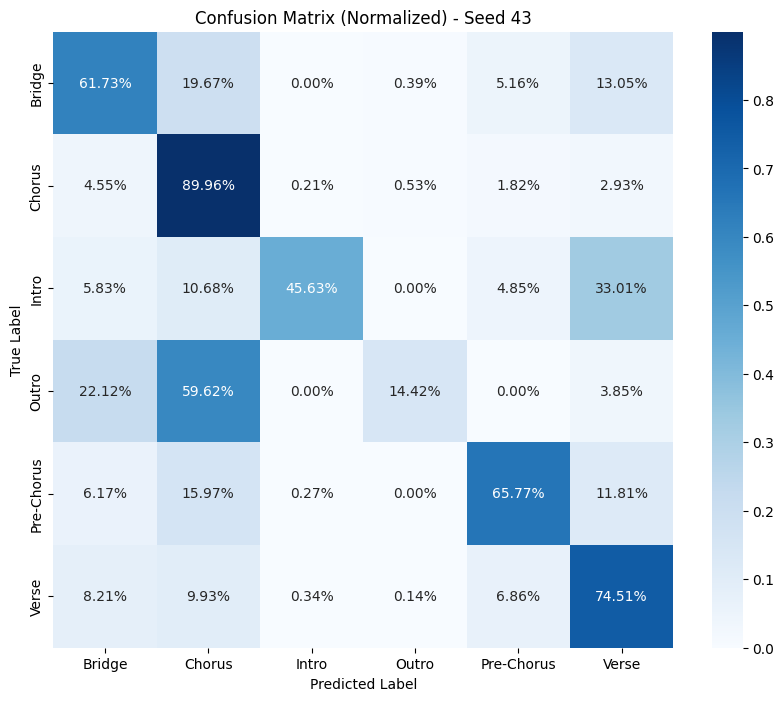


🏆 Seed 43 最終詳細評估報告 (Final Detailed Report)
            指標 (Metric)      數值 (Value)
      Weighted F1-Score 0.7848 ± 0.0178
         Hit Rate @0.5s          0.7867
Hit Rate @3s (Window=1) 0.8265 ± 0.0154
              L-Measure          0.7867
        Peak VRAM Usage        565.1 MB
       System RAM Usage         1.67 GB
         Time per Epoch             N/A

【段落詳細 F1 統計 (已排除 Outro=0 的 fold)】
● Bridge      : 0.5649 (±0.0796)
● Chorus      : 0.8782 (±0.0108)
● Intro       : 0.5798 (±0.0497)
● Outro       : 0.4429 (±0.2492)
● Pre-Chorus  : 0.6210 (±0.0183)
● Verse       : 0.7830 (±0.0300)


In [ ]:
# ==========================================
# Combine outputs
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

all_true = []
all_pred = []
all_h3_list = []

print("⏳ 正在彙整所有 Fold 的預測數據以生成混淆矩陣與 Hit@3s...")

for fold, (train_idx, val_idx) in enumerate(kf_target.split(data_cache)):
    val_ds = Subset(AblationDataset(data_cache), val_idx)
    model_fold = OptimizedBiLSTM_Dynamic(1540, len(label_encoder.classes_)).to(device)
    model_fold.load_state_dict(temp_fold_models[fold])
    model_fold.eval()

    y_true_fold, y_pred_fold = [], []
    with torch.no_grad():
        for x, y in val_ds:
            out = model_fold(x.unsqueeze(0).to(device))
            preds = torch.argmax(out, dim=1).cpu().tolist()
            trues = y.tolist()

            y_true_fold.extend(trues)
            y_pred_fold.extend(preds)

            for t, p in zip(trues, preds):
                if t != inst_idx:
                    all_true.append(t)
                    all_pred.append(p)

    clean_t = [t for t in y_true_fold if t != inst_idx]
    clean_p = [p for t, p in zip(y_true_fold, y_pred_fold) if t != inst_idx]
    all_h3_list.append(get_metrics(clean_t, clean_p, window=1))

# Confusion Matrix
cm = confusion_matrix(all_true, all_pred)
cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_perc, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=eval_names, yticklabels=eval_names)
plt.title(f'Confusion Matrix (Normalized) - Seed {TARGET_SEED}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

try:
    vram_usage = f"{monitor.max_gpu_mem:.1f} MB"
except:
    vram_usage = f"{torch.cuda.max_memory_allocated()/1024**2:.1f} MB" if torch.cuda.is_available() else "0.0 MB"

try:
    ram_usage = f"{psutil.Process(os.getpid()).memory_info().rss / 1024**2 / 1024:.2f} GB"
except:
    ram_usage = "N/A"

try:
    avg_time = f"{np.mean(epoch_times):.3f} min" if 'epoch_times' in locals() else "N/A"
except:
    avg_time = "N/A"

summary_final = {
    "指標 (Metric)": [
        "Weighted F1-Score",
        "Hit Rate @0.5s",
        "Hit Rate @3s (Window=1)",
        "L-Measure",
        "Peak VRAM Usage",
        "System RAM Usage",
        "Time per Epoch"
    ],
    "數值 (Value)": [
        f"{summary_data['overall_avg_wf1']:.4f} ± {summary_data['overall_std_wf1']:.4f}",
        f"{summary_data['overall_avg_h05']:.4f}",
        f"{np.mean(all_h3_list):.4f} ± {np.std(all_h3_list):.4f}",
        f"{summary_data['overall_avg_l_measure']:.4f}",
        vram_usage,
        ram_usage,
        avg_time
    ]
}

print("\n" + "="*60)
print(f"🏆 Seed {TARGET_SEED} 最終詳細評估報告 (Final Detailed Report)")
print("="*60)
print(pd.DataFrame(summary_final).to_string(index=False))

print("\n【段落詳細 F1 統計 (已排除 Outro=0 的 fold)】")
for k, v in final_metrics_43.items():
    print(f"● {k:<12}: {v['mean']:.4f} (±{v['std']:.4f})")
print("="*60)

3.Proposed Bi-LSTM (Ablation Test)

In [ ]:
import os
import random
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import glob
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset, Subset
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel

from google.colab import drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# ============================================================
# Dataset Path
# ============================================================
# Please set this path to the location of your reconstructed
# dataset in your own Google Drive.
#
# DATA_DIR = "/content/drive/MyDrive/YOUR_DATASET_FOLDER"

DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/2025~2026_RY_Thesis/2025.1221_Processed_148_Common_Lyrics/148_Aligned_Paragraph_Structure_Delete_Different"
ULTIMATE_MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/2025~2026_RY_Thesis/ultimate_encoder_model"
TARGET_SEED = 43
MAX_LEN = 256
TARGET_LABELS = ['Verse', 'Pre-Chorus', 'Chorus', 'Intro', 'Outro', 'Bridge', 'Instruments']
device = 'cuda' if torch.cuda.is_available() else 'cpu'

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(TARGET_SEED)

def get_pretrained_model(path):
    try:
        tok = AutoTokenizer.from_pretrained(path)
        mod = AutoModel.from_pretrained(path).to(device).eval()
        print(f"✅ 成功載入 Ultimate Model: {path}")
        return tok, mod
    except:
        print("⚠️ 找不到 Ultimate Model，降級使用 roberta-base")
        tok = AutoTokenizer.from_pretrained("roberta-base")
        mod = AutoModel.from_pretrained("roberta-base").to(device).eval()
        return tok, mod

def compute_cached_features(lyrics_list, section_texts, tokenizer, model, device):
    w_embs, batch_size = [], 32
    lines = [f"{' '.join(lyrics_list[max(0,i-2):i])} {tokenizer.sep_token} {lyrics_list[i]} {tokenizer.sep_token} {' '.join(lyrics_list[i+1:min(len(lyrics_list),i+3)])}" for i in range(len(lyrics_list))]
    with torch.no_grad():
        for i in range(0, len(lines), batch_size):
            batch = lines[i:i+batch_size]
            inp = tokenizer(batch, padding=True, truncation=True, max_length=MAX_LEN, return_tensors='pt').to(device)
            out = model(**inp).last_hidden_state
            mask = inp['attention_mask']
            emb = (out * mask.unsqueeze(-1)).sum(1) / mask.sum(1, keepdim=True).clamp(min=1e-9)
            w_embs.append(emb.cpu())
    w_tensor = torch.cat(w_embs, dim=0)

    unique_secs = list(set(section_texts))
    sec_map = {}
    with torch.no_grad():
        for i in range(0, len(unique_secs), batch_size):
            batch = unique_secs[i:i+batch_size]
            inp = tokenizer(batch, padding=True, truncation=True, max_length=MAX_LEN, return_tensors='pt').to(device)
            out = model(**inp).last_hidden_state
            mask = inp['attention_mask']
            emb = (out * mask.unsqueeze(-1)).sum(1) / mask.sum(1, keepdim=True).clamp(min=1e-9)
            res = emb.cpu()
            for j, txt in enumerate(batch): sec_map[txt] = res[j]
    s_tensor = torch.stack([sec_map[t] for t in section_texts])

    sim_matrix = cosine_similarity(w_tensor.numpy())
    rep_feats = []
    for i in range(len(lyrics_list)):
        sims = sim_matrix[i].copy(); sims[i] = -1.0
        rep_feats.append([sims.max(), float(sims.max() > 0.85), float((sims > 0.8).sum())])
    return w_tensor, s_tensor, torch.tensor(rep_feats, dtype=torch.float)

class AblationDataset(Dataset):
    def __init__(self, cache_list, variant):
        self.data = cache_list
        self.variant = variant
    def __len__(self): return len(self.data)
    def __getitem__(self, i):
        d = self.data[i]
        if self.variant == 'G':
            feats = [torch.zeros((d['w_emb'].shape[0], 1))]
        elif self.variant == 'F':
            feats = [d['s_emb']]
        elif self.variant == 'E':
            feats = [d['w_emb']]
        else:
            feats = [d['w_emb']]
            if self.variant in ['A', 'B', 'C', 'D']: feats.append(d['s_emb'])
            if self.variant in ['A', 'B']: feats.append(d['pos'].unsqueeze(1))
            if self.variant in ['A', 'C']: feats.append(d['rep'])
        return torch.cat(feats, dim=1), d['labels']

class OptimizedBiLSTM_Dynamic(nn.Module):
    def __init__(self, input_dim, n_classes):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=256, num_layers=2, batch_first=True, bidirectional=True, dropout=0.1)
        self.clf = nn.Sequential(nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.1), nn.Linear(256, n_classes))
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.clf(out.squeeze(0))

def get_metrics(y_true, y_pred, window=0):
    hits = 0
    for i in range(len(y_true)):
        start, end = max(0, i - window), min(len(y_true), i + window + 1)
        if y_true[i] in y_pred[start:end]: hits += 1
    return hits / len(y_true) if len(y_true) > 0 else 0

label_encoder = LabelEncoder().fit(TARGET_LABELS)
inst_idx = label_encoder.transform(['Instruments'])[0]

if 'data_cache' not in globals() or len(data_cache) == 0:
    print("🚀 正在預計算特徵快取 (此步驟較久，僅需執行一次)...")
    feat_tokenizer, feat_model = get_pretrained_model(ULTIMATE_MODEL_PATH)
    csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
    data_cache = []

    for f in tqdm(csv_files, desc="Processing CSVs"):
        try:
            df = pd.read_csv(f).dropna(subset=['lyrics', 'harmonix_section'])
            df = df[df['harmonix_section'].isin(TARGET_LABELS)].reset_index(drop=True)
            if len(df) == 0: continue
            df['group_id'] = (df['harmonix_section'] != df['harmonix_section'].shift()).cumsum()
            total_sections = df['group_id'].nunique()
            section_texts, rel_positions = [""] * len(df), [0.0] * len(df)
            group_rank_map = {gid: i for i, gid in enumerate(sorted(df['group_id'].unique()))}
            for gid, group in df.groupby('group_id'):
                full_txt = " ".join(group['lyrics'].astype(str).tolist())
                pos = group_rank_map[gid] / (total_sections - 1) if total_sections > 1 else 0.0
                for idx in group.index: section_texts[idx] = full_txt; rel_positions[idx] = pos
            w_t, s_t, r_t = compute_cached_features(df['lyrics'].astype(str).tolist(), section_texts, feat_tokenizer, feat_model, device)
            data_cache.append({'w_emb': w_t, 's_emb': s_t, 'rep': r_t, 'pos': torch.tensor(rel_positions, dtype=torch.float), 'labels': torch.tensor(label_encoder.transform(df['harmonix_section']), dtype=torch.long)})
        except Exception as e:
            print(f"Error processing {f}: {e}")
            continue
    del feat_model, feat_tokenizer; torch.cuda.empty_cache()

# Ablation Test
VARIANTS_CONFIG = {
    'A': {'name': 'Full Model', 'desc': 'Win+Sec+Pos+Rep', 'dim': 1540},
    'B': {'name': 'w/o Repetition', 'desc': 'Win+Sec+Pos', 'dim': 1537},
    'C': {'name': 'w/o Position', 'desc': 'Win+Sec+Rep', 'dim': 1539},
    'D': {'name': 'Content Only', 'desc': 'Win+Sec', 'dim': 1536},
    'E': {'name': 'Window Only', 'desc': 'Win Only', 'dim': 768},
    'F': {'name': 'Section Only', 'desc': 'Sec Only', 'dim': 768},
    'G': {'name': 'Zero Input', 'desc': 'No Features', 'dim': 1},
}

eval_names = [n for n in label_encoder.classes_ if n != 'Instruments']
ablation_summary = []

for v_key in ['A', 'B', 'C', 'D', 'E', 'F', 'G']:
    cfg = VARIANTS_CONFIG[v_key]
    print(f"\n" + "🔥" * 25 + f"\n🧪 正在測試變體 {v_key}: {cfg['name']}\n" + "🔥" * 25)

    v_results = []
    kf = KFold(n_splits=5, shuffle=True, random_state=TARGET_SEED)

    for fold, (train_idx, val_idx) in enumerate(kf.split(data_cache)):
        train_ds = Subset(AblationDataset(data_cache, v_key), train_idx)
        val_ds = Subset(AblationDataset(data_cache, v_key), val_idx)

        model = OptimizedBiLSTM_Dynamic(cfg['dim'], len(label_encoder.classes_)).to(device)
        optimizer = AdamW(model.parameters(), lr=1.8e-4, weight_decay=1e-3)
        criterion = nn.CrossEntropyLoss()

        for epoch in range(15):
            model.train()
            for x, y in train_ds:
                optimizer.zero_grad()
                out = model(x.unsqueeze(0).to(device))
                loss = criterion(out, y.to(device))
                loss.backward()
                optimizer.step()

        model.eval(); y_t, y_p = [], []
        with torch.no_grad():
            for x, y in val_ds:
                out = model(x.unsqueeze(0).to(device))
                y_p.extend(torch.argmax(out, dim=1).cpu().tolist())
                y_t.extend(y.tolist())

        clean_t = [t for t, p in zip(y_t, y_p) if t != inst_idx]
        clean_p = [p for t, p in zip(y_t, y_p) if t != inst_idx]

        wf1 = precision_recall_fscore_support(clean_t, clean_p, average='weighted', zero_division=0)[2]
        v_results.append({'wf1': wf1, 'h05': get_metrics(clean_t, clean_p, 0), 'report': classification_report(clean_t, clean_p, target_names=eval_names, output_dict=True, zero_division=0)})
        print(f"   Fold {fold+1} Done. WF1: {wf1:.4f}")
        del model; torch.cuda.empty_cache()

    avg_wf1 = np.mean([r['wf1'] for r in v_results])
    ablation_summary.append(f"Variant {v_key} ({cfg['desc']}): {avg_wf1:.4f}")
    print(f"\n✅ {cfg['name']} 平均 WF1: {avg_wf1:.4f}")

print("\n" + "="*50 + "\n🏁 消融實驗最終結果總結 (用於論文表格):")
for s in ablation_summary:
    print(s)
print("="*50)

Mounted at /content/drive
🚀 正在預計算特徵快取 (此步驟較久，僅需執行一次)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ 成功載入 Ultimate Model: /content/drive/MyDrive/Colab Notebooks/2025~2026_RY_Thesis/ultimate_encoder_model


Processing CSVs:   0%|          | 0/148 [00:00<?, ?it/s]


🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
🧪 正在測試變體 A: Full Model
🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
   Fold 1 Done. WF1: 0.7770
   Fold 2 Done. WF1: 0.8037
   Fold 3 Done. WF1: 0.8082
   Fold 4 Done. WF1: 0.7645
   Fold 5 Done. WF1: 0.7706

✅ Full Model 平均 WF1: 0.7848

🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
🧪 正在測試變體 B: w/o Repetition
🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
   Fold 1 Done. WF1: 0.7944
   Fold 2 Done. WF1: 0.7761
   Fold 3 Done. WF1: 0.8029
   Fold 4 Done. WF1: 0.7766
   Fold 5 Done. WF1: 0.7406

✅ w/o Repetition 平均 WF1: 0.7781

🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
🧪 正在測試變體 C: w/o Position
🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
   Fold 1 Done. WF1: 0.7649
   Fold 2 Done. WF1: 0.7929
   Fold 3 Done. WF1: 0.7977
   Fold 4 Done. WF1: 0.7999
   Fold 5 Done. WF1: 0.7389

✅ w/o Position 平均 WF1: 0.7789

🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
🧪 正在測試變體 D: Content Only
🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
   Fold 1 Done. WF1: 0.7765
   Fold 2 Done. WF1: 0.7672
   Fold 3 Done. WF1: 0.8248
   Fold 4 Done. WF1: 0.7977
   Fold 5 Done. WF1: 0.7362

✅ Content Only 平均 WF1: 0.7805

🔥🔥🔥

4.Baseline--SongFormer (seed=43)

In [ ]:
# ==============================================================================
# SongFormer Implementation
# ==============================================================================
import os, gc, warnings, re, time, psutil, math, glob, random
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import librosa
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score, accuracy_score
from tqdm.notebook import tqdm

try:
    import mir_eval
except ImportError:
    os.system('pip install mir_eval')
    import mir_eval

def set_seed(seed=43):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(43)
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
warnings.filterwarnings('ignore')

from google.colab import drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# ============================================================
# Dataset Path
# ============================================================
# Please set this path to the location of your reconstructed
# dataset in your own Google Drive.
#
# DIR_HARMONIX_GT = "/content/drive/MyDrive/YOUR_FOLDER"
# DIR_AUDIO_RAW = "/content/drive/MyDrive/YOUR_FOLDER"

DIR_HARMONIX_GT = "/content/drive/MyDrive/Colab Notebooks/2025~2026_RY_Thesis/2025.1221_Processed_148_Common_Lyrics/148_Common_Audio_Harmonix_Segments"
DIR_AUDIO_RAW = "/content/drive/MyDrive/Colab Notebooks/2025~2026_RY_Thesis/2025.1221_Processed_148_Common_Lyrics/148_Common_Audio_Files"

SAMPLE_RATE, HOP_LENGTH, N_MELS = 22050, 512, 128
CHUNK_DURATION = 30
INPUT_FRAMES = int(CHUNK_DURATION * SAMPLE_RATE / HOP_LENGTH) + 1
BATCH_SIZE, EPOCHS, LEARNING_RATE = 16, 15, 1e-4

TARGET_LABELS = ['Bridge', 'Chorus', 'Intro', 'Outro', 'Pre-Chorus', 'Verse']
LABEL_MAPPING = {
    'intro': 'Intro', 'verse': 'Verse', 'pre-chorus': 'Pre-Chorus',
    'pre_chorus': 'Pre-Chorus', 'prechorus': 'Pre-Chorus',
    'chorus': 'Chorus', 'bridge': 'Bridge', 'solo': 'Chorus',
    'instrumental': 'Chorus', 'outro': 'Outro'
}

device = 'cuda' if torch.cuda.is_available() else 'cpu'
label_encoder = LabelEncoder().fit(TARGET_LABELS)

class SongFormer(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d((4, 4)),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d((4, 4)),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d((2, 2))
        )
        encoder_layer = nn.TransformerEncoderLayer(d_model=512, nhead=8, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=4)
        self.fc = nn.LazyLinear(num_classes)

    def forward(self, x):
        x = self.conv_block(x)
        b, c, h, w = x.shape
        x = x.permute(0, 3, 1, 2).reshape(b, w, c * h)
        x = self.transformer_encoder(x)
        return self.fc(torch.cat([torch.mean(x, 1), torch.max(x, 1)[0]], 1))

def calculate_boundary_hit(y_true_bounds, y_pred_bounds, window=3.0):
    if len(y_pred_bounds) == 0: return 0.0
    hits = 0
    used_true = set()
    for p in y_pred_bounds:
        for i, t in enumerate(y_true_bounds):
            if abs(p - t) <= window and i not in used_true:
                hits += 1
                used_true.add(i)
                break
    p_val = hits / len(y_pred_bounds) if len(y_pred_bounds) > 0 else 0
    r_val = hits / len(y_true_bounds) if len(y_true_bounds) > 0 else 0
    return (2 * p_val * r_val) / (p_val + r_val) if (p_val + r_val) > 0 else 0

def load_melspec(path, start, end):
    try:
        y, _ = librosa.load(path, sr=SAMPLE_RATE, offset=start, duration=end-start)
        mel = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=SAMPLE_RATE, n_mels=N_MELS), ref=np.max)
        t = torch.tensor(mel).unsqueeze(0)
        if t.shape[2] > INPUT_FRAMES: t = t[:, :, :INPUT_FRAMES]
        else: t = F.pad(t, (0, INPUT_FRAMES - t.shape[2]))
        return (t - t.mean()) / (t.std() + 1e-6)
    except: return None

try:
    if 'all_songs_data' in globals() and len(all_songs_data) > 0:
        print(f"♻️ 偵測到已存在的資料快取，包含 {len(all_songs_data)} 首歌曲。跳過載入步驟。")
    else:
        raise NameError
except NameError:
    print("⏳ 記憶體中無資料，開始從雲端硬碟讀取音訊特徵...")
    all_songs_data = []
    audio_files = {re.sub(r'[^a-z0-9]', '', os.path.splitext(os.path.basename(f))[0].lower()): os.path.join(DIR_AUDIO_RAW, f)
                   for f in os.listdir(DIR_AUDIO_RAW) if f.endswith('.mp3')}
    txt_files = glob.glob(os.path.join(DIR_HARMONIX_GT, "*.txt"))

    for f in tqdm(txt_files, desc="Processing Songs"):
        name = re.sub(r'[^a-z0-9]', '', os.path.splitext(os.path.basename(f))[0].lower())
        if name not in audio_files: continue
        song_segs = []
        try:
            df = pd.read_csv(f, sep=r'\s+', header=None, names=['time', 'label'])
            for i in range(len(df)-1):
                lbl = str(df.iloc[i]['label']).lower()
                if lbl in LABEL_MAPPING:
                    spec = load_melspec(audio_files[name], df.iloc[i]['time'], df.iloc[i+1]['time'])
                    if spec is not None:
                        song_segs.append({
                            'input': spec, 'label_idx': label_encoder.transform([LABEL_MAPPING[lbl]])[0],
                            'label_str': LABEL_MAPPING[lbl], 'interval': (df.iloc[i]['time'], df.iloc[i+1]['time'])
                        })
            if song_segs: all_songs_data.append({'segments': song_segs, 'gt_bounds': df['time'].tolist()})
        except: continue
    print(f"✅ 資料載入完成，共計 {len(all_songs_data)} 首歌曲。")

class SongDataset(Dataset):
    def __init__(self, d): self.d = d
    def __len__(self): return len(self.d)
    def __getitem__(self, i): return self.d[i]


fold_logs = []
section_stats = {lbl: {'p': [], 'r': [], 'f1': []} for lbl in TARGET_LABELS}
kf = KFold(n_splits=5, shuffle=True, random_state=43)

print(f"\n🚀 開始 5-Fold 交叉驗證...")

for fold, (t_idx, v_idx) in enumerate(kf.split(all_songs_data)):
    fold_start = time.time()
    train_list = [seg for i in t_idx for seg in all_songs_data[i]['segments']]
    val_songs = [all_songs_data[i] for i in v_idx]

    model = SongFormer(len(TARGET_LABELS)).to(device)
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()
    train_loader = DataLoader(SongDataset(train_list), batch_size=BATCH_SIZE, shuffle=True)

    # Training
    model.train()
    for epoch in range(EPOCHS):
        for batch in train_loader:
            optimizer.zero_grad()
            out = model(batch['input'].to(device))
            loss = criterion(out, batch['label_idx'].to(device))
            loss.backward()
            optimizer.step()

    # Evaluation
    model.eval()
    all_p, all_t = [], []
    fold_hits, fold_l_measures = [] , []

    with torch.no_grad():
        for song_data in val_songs:
            s_intervals = np.array([s['interval'] for s in song_data['segments']])
            s_labels_gt = [s['label_str'] for s in song_data['segments']]
            if s_intervals[0, 0] != 0: s_intervals[0, 0] = 0.0 # 修正 mir_eval 起點

            inputs = torch.stack([s['input'] for s in song_data['segments']]).to(device)
            preds_idx = model(inputs).argmax(1).cpu().numpy()
            s_labels_est = label_encoder.inverse_transform(preds_idx)

            all_p.extend(preds_idx)
            all_t.extend([s['label_idx'] for s in song_data['segments']])

            pred_bounds = [s_intervals[0, 0]]
            for j in range(1, len(s_labels_est)):
                if s_labels_est[j] != s_labels_est[j-1]:
                    pred_bounds.append(s_intervals[j, 0])

            # Hit@3s & L-Measure
            fold_hits.append(calculate_boundary_hit(song_data['gt_bounds'], pred_bounds, 3.0))
            try:
                _, _, f_pair = mir_eval.segment.pairwise(s_intervals, s_labels_gt, s_intervals, s_labels_est)
                fold_l_measures.append(f_pair)
            except: continue

    f1_w = f1_score(all_t, all_p, average='weighted', zero_division=0)
    acc = accuracy_score(all_t, all_p)
    h3, l_m = np.mean(fold_hits), np.mean(fold_l_measures)

    report = classification_report(all_t, all_p, labels=range(len(TARGET_LABELS)), target_names=TARGET_LABELS, output_dict=True, zero_division=0)
    for lbl in TARGET_LABELS:
        section_stats[lbl]['p'].append(report[lbl]['precision'])
        section_stats[lbl]['r'].append(report[lbl]['recall'])
        section_stats[lbl]['f1'].append(report[lbl]['f1-score'])

    fold_logs.append([fold+1, f1_w, acc, h3, l_m])
    print(f"✅ Fold {fold+1} 完成 | F1: {f1_w:.4f} | Acc: {acc:.4f} | Hit@3s: {h3:.4f} | L-M: {l_m:.4f}")
    del model; gc.collect(); torch.cuda.empty_cache()

# Print
print("\n" + "="*95)
print("【 1. 總體指標彙整報告 (Overall Metrics: Mean ± Std) 】")
res_arr = np.array(fold_logs)
metrics_list = ["Weighted F1", "Accuracy", "Hit@3s", "L-Measure"]

for i, name in enumerate(metrics_list):
    mean_val, std_val = np.mean(res_arr[:, i+1]), np.std(res_arr[:, i+1])
    print(f"● {name:<15}: {mean_val:.4f} ± {std_val:.4f}")

print("\n" + "-"*95)
print("【 2. 各類別分類詳細指標 (Mean ± Std) 】")
print(f"{'Section':<12} | {'Precision':<18} | {'Recall':<18} | {'F1-Score':<18}")
print("-" * 75)
for lbl in TARGET_LABELS:
    p_m, p_s = np.mean(section_stats[lbl]['p']), np.std(section_stats[lbl]['p'])
    r_m, r_s = np.mean(section_stats[lbl]['r']), np.std(section_stats[lbl]['r'])
    f_m, f_s = np.mean(section_stats[lbl]['f1']), np.std(section_stats[lbl]['f1'])
    print(f"{lbl:<12} | {p_m:.4f} ± {p_s:.4f} | {r_m:.4f} ± {r_s:.4f} | {f_m:.4f} ± {f_s:.4f}")
print("="*95)

♻️ 偵測到已存在的資料快取，包含 148 首歌曲。跳過載入步驟。

🚀 開始 5-Fold 交叉驗證...
✅ Fold 1 完成 | F1: 0.4932 | Acc: 0.5265 | Hit@3s: 0.6005 | L-M: 0.6261
✅ Fold 2 完成 | F1: 0.5707 | Acc: 0.5719 | Hit@3s: 0.7583 | L-M: 0.6418
✅ Fold 3 完成 | F1: 0.5223 | Acc: 0.5627 | Hit@3s: 0.6456 | L-M: 0.6234
✅ Fold 4 完成 | F1: 0.5221 | Acc: 0.5390 | Hit@3s: 0.6701 | L-M: 0.6166
✅ Fold 5 完成 | F1: 0.5185 | Acc: 0.5240 | Hit@3s: 0.8038 | L-M: 0.6336

【 1. 總體指標彙整報告 (Overall Metrics: Mean ± Std) 】
● Weighted F1    : 0.5254 ± 0.0251
● Accuracy       : 0.5448 ± 0.0193
● Hit@3s         : 0.6957 ± 0.0746
● L-Measure      : 0.6283 ± 0.0087

-----------------------------------------------------------------------------------------------
【 2. 各類別分類詳細指標 (Mean ± Std) 】
Section      | Precision          | Recall             | F1-Score          
---------------------------------------------------------------------------
Bridge       | 0.1036 ± 0.0948 | 0.0947 ± 0.0906 | 0.0971 ± 0.0908
Chorus       | 0.6160 ± 0.0448 | 0.6018 ± 0.0431 | 0.6067 ± 0.

5.Baseline--LongFormer (seed= 43)

In [ ]:
# ==============================================================================
# Longformer Implementation
# ==============================================================================
import os, gc, warnings, re, time, psutil, math, glob, random
import torch
import pandas as pd
import numpy as np
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, Subset
from torch.optim import AdamW
from transformers import LongformerTokenizerFast, LongformerForTokenClassification
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score
from tqdm.notebook import tqdm

try:
    import mir_eval
except ImportError:
    os.system('pip install mir_eval')
    import mir_eval

def set_seed(seed=43):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(43)
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
warnings.filterwarnings('ignore')

from google.colab import drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/2025~2026_RY_Thesis/2025.1221_Processed_148_Common_Lyrics/148_Aligned_Paragraph_Structure_Delete_Different"
MODEL_NAME = "allenai/longformer-base-4096"
MAX_LEN = 2048
BATCH_SIZE = 1
EPOCHS = 3
LR = 2e-5
TARGET_LABELS = ['Verse', 'Pre-Chorus', 'Chorus', 'Intro', 'Outro', 'Bridge', 'Instruments']

device = 'cuda' if torch.cuda.is_available() else 'cpu'
label_encoder = LabelEncoder().fit(TARGET_LABELS)
label2id = {l: i for i, l in enumerate(label_encoder.classes_)}
id2label = {i: l for i, l in enumerate(label_encoder.classes_)}

tokenizer = LongformerTokenizerFast.from_pretrained(MODEL_NAME)

try:
    if 'longformer_data' in globals() and len(longformer_data) > 0:
        print(f"♻️ 偵測到已存在的 Longformer 資料快取，包含 {len(longformer_data)} 首歌曲。")
    else:
        raise NameError
except NameError:
    print("⏳ 正在 Tokenize 歌曲資料...")
    def process_song(file_path):
        try:
            df = pd.read_csv(file_path).dropna(subset=['lyrics', 'harmonix_section'])
            df = df[df['harmonix_section'].isin(TARGET_LABELS)]
            if len(df) == 0: return None
            intervals = []
            start_times = df['start_time'].tolist() if 'start_time' in df.columns else list(range(len(df)))
            for i in range(len(start_times)):
                end = start_times[i+1] if i+1 < len(start_times) else start_times[i] + 30
                intervals.append((start_times[i], end))

            lyrics, labels = df['lyrics'].astype(str).tolist(), label_encoder.transform(df['harmonix_section']).tolist()
            full_ids, full_labels = [], []
            bos_id = tokenizer.bos_token_id
            for line, label in zip(lyrics, labels):
                line_ids = tokenizer.encode(line, add_special_tokens=False)
                full_ids.append(bos_id); full_labels.append(label)
                full_ids.extend(line_ids); full_labels.extend([-100] * len(line_ids))

            if len(full_ids) > MAX_LEN:
                full_ids, full_labels = full_ids[:MAX_LEN], full_labels[:MAX_LEN]

            return {
                'input_ids': torch.tensor(full_ids, dtype=torch.long),
                'attention_mask': torch.tensor([1]*len(full_ids), dtype=torch.long),
                'global_attention_mask': torch.tensor([1]+[0]*(len(full_ids)-1), dtype=torch.long),
                'labels': torch.tensor(full_labels, dtype=torch.long),
                'intervals': np.array(intervals),
                'gt_labels': label_encoder.inverse_transform(labels),
                'gt_bounds': start_times
            }
        except: return None

    csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
    longformer_data = [process_song(f) for f in tqdm(csv_files) if process_song(f) is not None]

def calculate_boundary_hit(y_true_bounds, y_pred_bounds, window=3.0):
    if len(y_pred_bounds) == 0: return 0.0
    hits = 0; used_true = set()
    for p in y_pred_bounds:
        for i, t in enumerate(y_true_bounds):
            if abs(p - t) <= window and i not in used_true:
                hits += 1; used_true.add(i); break
    p_v = hits / len(y_pred_bounds) if len(y_pred_bounds) > 0 else 0
    r_v = hits / len(y_true_bounds) if len(y_true_bounds) > 0 else 0
    return (2 * p_v * r_v) / (p_v + r_v) if (p_v + r_v) > 0 else 0

kf = KFold(n_splits=5, shuffle=True, random_state=43)
fold_logs = []
section_stats = {lbl: {'p': [], 'r': [], 'f1': []} for lbl in TARGET_LABELS}

print(f"\n🚀 開始 Longformer 5-Fold CV")

for fold, (train_idx, val_idx) in enumerate(kf.split(longformer_data)):
    fold_start = time.time()
    model = LongformerForTokenClassification.from_pretrained(MODEL_NAME, num_labels=len(TARGET_LABELS), id2label=id2label, label2id=label2id)
    model.gradient_checkpointing_enable(); model.to(device)
    optimizer = AdamW(model.parameters(), lr=LR)

    train_ds = [longformer_data[i] for i in train_idx]
    val_ds = [longformer_data[i] for i in val_idx]

    for epoch in range(EPOCHS):
        model.train()
        for batch in tqdm(train_ds, desc=f"Fold {fold+1} Ep {epoch+1}", leave=False):
            inputs = {k: v.unsqueeze(0).to(device) for k, v in batch.items() if k in ['input_ids', 'attention_mask', 'global_attention_mask', 'labels']}
            outputs = model(**inputs); outputs.loss.backward()
            optimizer.step(); optimizer.zero_grad()

    # Evaluation
    model.eval()
    all_p, all_t = [], []
    fold_hits, fold_l_measures = [], []

    with torch.no_grad():
        for batch in val_ds:
            inputs = {k: v.unsqueeze(0).to(device) for k, v in batch.items() if k in ['input_ids', 'attention_mask', 'global_attention_mask', 'labels']}
            logits = model(**inputs).logits
            preds = torch.argmax(logits, dim=2).squeeze(0).cpu()
            labs = batch['labels']
            active = labs != -100

            p_filtered = preds[active].tolist()
            t_filtered = labs[active].tolist()
            all_p.extend(p_filtered); all_t.extend(t_filtered)

            s_intervals = batch['intervals']
            s_labels_gt = batch['gt_labels']
            s_labels_est = label_encoder.inverse_transform(p_filtered)

            if s_intervals[0, 0] != 0: s_intervals[0, 0] = 0.0

            pred_bounds = [s_intervals[0, 0]]
            for j in range(1, len(s_labels_est)):
                if s_labels_est[j] != s_labels_est[j-1]:
                    pred_bounds.append(s_intervals[j, 0])

            fold_hits.append(calculate_boundary_hit(batch['gt_bounds'], pred_bounds, 3.0))
            try:
                _, _, f_pair = mir_eval.segment.pairwise(s_intervals, s_labels_gt, s_intervals, s_labels_est)
                fold_l_measures.append(f_pair)
            except: continue

    f1_w = f1_score(all_t, all_p, average='weighted', zero_division=0)
    acc = accuracy_score(all_t, all_p)
    h3, l_m = np.mean(fold_hits), np.mean(fold_l_measures)

    report = classification_report(all_t, all_p, labels=range(len(TARGET_LABELS)), target_names=TARGET_LABELS, output_dict=True, zero_division=0)
    for lbl in TARGET_LABELS:
        section_stats[lbl]['p'].append(report[lbl]['precision'])
        section_stats[lbl]['r'].append(report[lbl]['recall'])
        section_stats[lbl]['f1'].append(report[lbl]['f1-score'])

    fold_logs.append([fold+1, f1_w, acc, h3, l_m])
    print(f"✅ Fold {fold+1} 完成 | F1: {f1_w:.4f} | Acc: {acc:.4f} | Hit@3s: {h3:.4f} | L-M: {l_m:.4f}")
    del model; torch.cuda.empty_cache(); gc.collect()

# Print
print("\n" + "="*95)
print("【 1. 總體指標彙整報告 (Overall Metrics: Mean ± Std) 】")
res_arr = np.array(fold_logs)
metrics_list = ["Weighted F1", "Accuracy", "Hit@3s", "L-Measure"]

for i, name in enumerate(metrics_list):
    mean_val, std_val = np.mean(res_arr[:, i+1]), np.std(res_arr[:, i+1])
    print(f"● {name:<15}: {mean_val:.4f} ± {std_val:.4f}")

print("\n" + "-"*95)
print("【 2. 各類別分類詳細指標 (Mean ± Std) 】")
print(f"{'Section':<12} | {'Precision':<18} | {'Recall':<18} | {'F1-Score':<18}")
print("-" * 75)
for lbl in TARGET_LABELS:
    p_m, p_s = np.mean(section_stats[lbl]['p']), np.std(section_stats[lbl]['p'])
    r_m, r_s = np.mean(section_stats[lbl]['r']), np.std(section_stats[lbl]['r'])
    f_m, f_s = np.mean(section_stats[lbl]['f1']), np.std(section_stats[lbl]['f1'])
    print(f"{lbl:<12} | {p_m:.4f} ± {p_s:.4f} | {r_m:.4f} ± {r_s:.4f} | {f_m:.4f} ± {f_s:.4f}")
print("="*95)

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

⏳ 正在 Tokenize 歌曲資料...


  0%|          | 0/148 [00:00<?, ?it/s]

...

LongformerForTokenClassification LOAD REPORT from: allenai/longformer-base-4096
Key                            | Status     | 
-------------------------------+------------+-
longformer.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight      | UNEXPECTED | 
lm_head.dense.bias             | UNEXPECTED | 
lm_head.decoder.weight         | UNEXPECTED | 
lm_head.bias                   | UNEXPECTED | 
lm_head.layer_norm.bias        | UNEXPECTED | 
longformer.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight           | UNEXPECTED | 
classifier.weight              | MISSING    | 
classifier.bias                | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 5 Ep 1:   0%|          | 0/119 [00:00<?, ?it/s]

Fold 5 Ep 2:   0%|          | 0/119 [00:00<?, ?it/s]

Fold 5 Ep 3:   0%|          | 0/119 [00:00<?, ?it/s]

✅ Fold 5 完成 | F1: 0.5485 | Acc: 0.5966 | Hit@3s: 0.1671 | L-M: 0.5938

【 1. 總體指標彙整報告 (Overall Metrics: Mean ± Std) 】
● Weighted F1    : 0.5672 ± 0.0408
● Accuracy       : 0.6142 ± 0.0397
● Hit@3s         : 0.1864 ± 0.0197
● L-Measure      : 0.6398 ± 0.0432

-----------------------------------------------------------------------------------------------
【 2. 各類別分類詳細指標 (Mean ± Std) 】
Section      | Precision          | Recall             | F1-Score          
---------------------------------------------------------------------------
Verse        | 0.4394 ± 0.1451 | 0.2200 ± 0.0864 | 0.2904 ± 0.1075
Pre-Chorus   | 0.6296 ± 0.0579 | 0.8414 ± 0.0124 | 0.7188 ± 0.0392
Chorus       | 0.0000 ± 0.0000 | 0.0000 ± 0.0000 | 0.0000 ± 0.0000
Intro        | 0.3200 ± 0.1939 | 0.0286 ± 0.0145 | 0.0517 ± 0.0259
Outro        | 0.0000 ± 0.0000 | 0.0000 ± 0.0000 | 0.0000 ± 0.0000
Bridge       | 0.0812 ± 0.0994 | 0.0116 ± 0.0145 | 0.0202 ± 0.0252
Instruments  | 0.6199 ± 0.0283 | 0.6053 ± 0.0761 | 0.6099 ± 0.

6.Proposed Bi-LSTM (Modified)

In [ ]:
import os
import copy
import json
import time
import glob
import random
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.optim import AdamW
from torch.utils.data import Dataset, Subset
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm

from transformers import AutoTokenizer, AutoModel

try:
    import mir_eval
except ImportError:
    os.system('pip install mir_eval')
    import mir_eval

from google.colab import drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# ============================================================
# Dataset Path
# ============================================================
# Please set this path to the location of your reconstructed
# dataset in your own Google Drive.
#
# DATA_DIR = "/content/drive/MyDrive/YOUR_DATASET_FOLDER"

DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/2025~2026_RY_Thesis/2025.1221_Processed_148_Common_Lyrics/148_Aligned_Paragraph_Structure_Delete_Different"
ULTIMATE_MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/2025~2026_RY_Thesis/ultimate_encoder_model"
SAVE_DIR_43 = "/content/drive/MyDrive/Colab Notebooks/2025~2026_RY_Thesis/Model_Pack_Seed43"
os.makedirs(SAVE_DIR_43, exist_ok=True)

MAX_LEN = 256
TARGET_LABELS = ['Verse', 'Pre-Chorus', 'Chorus', 'Intro', 'Outro', 'Bridge', 'Instruments']
TARGET_SEED = 43
device = 'cuda' if torch.cuda.is_available() else 'cpu'

label_encoder = LabelEncoder().fit(TARGET_LABELS)
inst_idx = list(label_encoder.classes_).index('Instruments')

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(TARGET_SEED)

class OptimizedBiLSTM_Dynamic(nn.Module):
    def __init__(self, input_dim, n_classes):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=256, num_layers=2, batch_first=True, bidirectional=True, dropout=0.1)
        self.clf = nn.Sequential(nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.1), nn.Linear(256, n_classes))
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.clf(out.squeeze(0))

class AblationDataset(Dataset):
    def __init__(self, cache_list): self.data = cache_list
    def __len__(self): return len(self.data)
    def __getitem__(self, i):
        d = self.data[i]
        x = torch.cat([d['w_emb'], d['s_emb'], d['pos'].unsqueeze(1), d['rep']], dim=1)
        return x, d['labels']

def calculate_boundary_hit(y_true_bounds, y_pred_bounds, window=3.0):
    if len(y_pred_bounds) == 0: return 0.0
    hits = 0; used_true = set()
    for p in y_pred_bounds:
        for i, t in enumerate(y_true_bounds):
            if abs(p - t) <= window and i not in used_true:
                hits += 1; used_true.add(i); break
    p_v = hits / len(y_pred_bounds) if len(y_pred_bounds) > 0 else 0
    r_v = hits / len(y_true_bounds) if len(y_true_bounds) > 0 else 0
    return (2 * p_v * r_v) / (p_v + r_v) if (p_v + r_v) > 0 else 0

def compute_cached_features(lyrics_list, section_texts, tokenizer, model, device):
    w_embs, batch_size = [], 32
    lines = [f"{' '.join(lyrics_list[max(0,i-2):i])} {tokenizer.sep_token} {lyrics_list[i]} {tokenizer.sep_token} {' '.join(lyrics_list[i+1:min(len(lyrics_list),i+3)])}" for i in range(len(lyrics_list))]
    with torch.no_grad():
        for i in range(0, len(lines), batch_size):
            batch = lines[i:i+batch_size]
            inp = tokenizer(batch, padding=True, truncation=True, max_length=MAX_LEN, return_tensors='pt').to(device)
            out = model(**inp).last_hidden_state
            mask = inp['attention_mask']
            emb = (out * mask.unsqueeze(-1)).sum(1) / mask.sum(1, keepdim=True).clamp(min=1e-9)
            w_embs.append(emb.cpu())
    w_tensor = torch.cat(w_embs, dim=0)

    unique_secs = list(set(section_texts))
    sec_map = {}
    with torch.no_grad():
        for i in range(0, len(unique_secs), batch_size):
            batch = unique_secs[i:i+batch_size]
            inp = tokenizer(batch, padding=True, truncation=True, max_length=MAX_LEN, return_tensors='pt').to(device)
            out = model(**inp).last_hidden_state
            mask = inp['attention_mask']
            emb = (out * mask.unsqueeze(-1)).sum(1) / mask.sum(1, keepdim=True).clamp(min=1e-9)
            for j, txt in enumerate(batch): sec_map[txt] = emb.cpu()[j]

    s_tensor = torch.stack([sec_map[t] for t in section_texts])
    sim_matrix = cosine_similarity(w_tensor.numpy())
    rep_feats = []
    for i in range(len(lyrics_list)):
        sims = sim_matrix[i].copy(); sims[i] = -1.0
        rep_feats.append([sims.max(), float(sims.max() > 0.85), float((sims > 0.8).sum())])
    return w_tensor, s_tensor, torch.tensor(rep_feats, dtype=torch.float)

print("🚀 正在初始化 Encoder 並預計算特徵...")
feat_tokenizer = AutoTokenizer.from_pretrained(ULTIMATE_MODEL_PATH if os.path.exists(ULTIMATE_MODEL_PATH) else "roberta-base")
feat_model = AutoModel.from_pretrained(ULTIMATE_MODEL_PATH if os.path.exists(ULTIMATE_MODEL_PATH) else "roberta-base").to(device).eval()

csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
data_cache = []

for f in tqdm(csv_files, desc="Processing Songs"):
    try:
        df = pd.read_csv(f).dropna(subset=['lyrics', 'harmonix_section'])
        df = df[df['harmonix_section'].isin(TARGET_LABELS)].reset_index(drop=True)
        if len(df) == 0: continue

        start_times = df['start_time'].tolist() if 'start_time' in df.columns else list(range(len(df)))
        intervals = []
        for i in range(len(start_times)):
            end = start_times[i+1] if i+1 < len(start_times) else start_times[i] + 30
            intervals.append([start_times[i], end])

        df['group_id'] = (df['harmonix_section'] != df['harmonix_section'].shift()).cumsum()
        total_sections = df['group_id'].nunique()
        section_texts, rel_positions = [""] * len(df), [0.0] * len(df)
        group_rank_map = {gid: i for i, gid in enumerate(sorted(df['group_id'].unique()))}
        for gid, group in df.groupby('group_id'):
            full_txt = " ".join(group['lyrics'].astype(str).tolist())
            pos = group_rank_map[gid] / (total_sections - 1) if total_sections > 1 else 0.0
            for idx in group.index: section_texts[idx] = full_txt; rel_positions[idx] = pos

        w_t, s_t, r_t = compute_cached_features(df['lyrics'].astype(str).tolist(), section_texts, feat_tokenizer, feat_model, device)
        data_cache.append({
            'w_emb': w_t, 's_emb': s_t, 'rep': r_t,
            'pos': torch.tensor(rel_positions, dtype=torch.float),
            'labels': torch.tensor(label_encoder.transform(df['harmonix_section']), dtype=torch.long),
            'intervals': np.array(intervals),
            'gt_bounds': start_times
        })
    except: continue

del feat_model; torch.cuda.empty_cache()

kf = KFold(n_splits=5, shuffle=True, random_state=TARGET_SEED)
target_run_results = []
temp_fold_models = []
eval_names = [n for n in label_encoder.classes_ if n != 'Instruments']

print(f"\n🚀 開始執行 Seed {TARGET_SEED} 的 5-Fold 驗證...")

for fold, (train_idx, val_idx) in enumerate(kf.split(data_cache)):
    train_ds = Subset(AblationDataset(data_cache), train_idx)
    val_items = [data_cache[i] for i in val_idx]

    model = OptimizedBiLSTM_Dynamic(1540, len(label_encoder.classes_)).to(device)
    optimizer = AdamW(model.parameters(), lr=1.8e-4, weight_decay=1e-3)
    criterion = nn.CrossEntropyLoss()

    model.train()
    for epoch in range(15):
        for x, y in train_ds:
            optimizer.zero_grad()
            out = model(x.unsqueeze(0).to(device))
            loss = criterion(out, y.to(device))
            loss.backward()
            optimizer.step()

    temp_fold_models.append(copy.deepcopy(model.state_dict()))

    model.eval()
    y_true_all, y_pred_all = [], []
    fold_hits_3s, fold_l_measures = [], []

    with torch.no_grad():
        for item in val_items:
            x = torch.cat([item['w_emb'], item['s_emb'], item['pos'].unsqueeze(1), item['rep']], dim=1).unsqueeze(0).to(device)
            out = model(x)
            preds = torch.argmax(out, dim=1).cpu().numpy()
            trues = item['labels'].numpy()

            valid_mask = (trues != inst_idx)
            if not np.any(valid_mask): continue

            clean_t = trues[valid_mask]
            clean_p = preds[valid_mask]
            y_true_all.extend(clean_t.tolist()); y_pred_all.extend(clean_p.tolist())

            # 1. Hit@3s
            s_labels_est = label_encoder.inverse_transform(preds)
            pred_bounds = [item['intervals'][0, 0]]
            for j in range(1, len(s_labels_est)):
                if s_labels_est[j] != s_labels_est[j-1]:
                    pred_bounds.append(item['intervals'][j, 0])
            fold_hits_3s.append(calculate_boundary_hit(item['gt_bounds'], pred_bounds, 3.0))

            # 2. L-Measure (Pairwise)
            clean_intervals = item['intervals'][valid_mask]
            if len(clean_intervals) > 0:
                clean_intervals_shifted = clean_intervals.copy()
                clean_intervals_shifted -= clean_intervals_shifted[0, 0]
                gt_labels_str = label_encoder.inverse_transform(clean_t)
                est_labels_str = label_encoder.inverse_transform(clean_p)
                try:
                    _, _, f_pair = mir_eval.segment.pairwise(clean_intervals_shifted, gt_labels_str, clean_intervals_shifted, est_labels_str)
                    if not np.isnan(f_pair): fold_l_measures.append(f_pair)
                except: pass

    target_run_results.append({
        'wf1': f1_score(y_true_all, y_pred_all, average='weighted', zero_division=0),
        'acc': accuracy_score(y_true_all, y_pred_all),
        'h3s': np.mean(fold_hits_3s) if fold_hits_3s else 0.0,
        'l_measure': np.mean(fold_l_measures) if fold_l_measures else 0.0,
        'report': classification_report(y_true_all, y_pred_all, target_names=eval_names, output_dict=True, zero_division=0)
    })
    print(f"   Fold {fold+1} 完成評估...")
    del model; torch.cuda.empty_cache()

# Output
final_metrics_43 = {}
for label in eval_names:
    f1_list = [r['report'].get(label, {}).get('f1-score', 0) for r in target_run_results]
    if label == 'Outro': f1_list = [f1 for f1 in f1_list if f1 != 0]
    final_metrics_43[label] = {'mean': np.mean(f1_list), 'std': np.std(f1_list)}

all_wf1 = [r['wf1'] for r in target_run_results]
all_acc = [r['acc'] for r in target_run_results]
all_h3s = [r['h3s'] for r in target_run_results]
all_l_measure = [r['l_measure'] for r in target_run_results]

summary_data = {
    'seed': TARGET_SEED,
    'wf1_mean': np.mean(all_wf1), 'wf1_std': np.std(all_wf1),
    'acc_mean': np.mean(all_acc), 'acc_std': np.std(all_acc),
    'h3s_mean': np.mean(all_h3s), 'h3s_std': np.std(all_h3s),
    'l_measure_mean': np.mean(all_l_measure), 'l_measure_std': np.std(all_l_measure),
    'paragraph_detailed_metrics': final_metrics_43
}

torch.save(summary_data, os.path.join(SAVE_DIR_43, f"metrics_seed{TARGET_SEED}.pt"))

# Print
print("\n" + "="*85)
print(f"📊 Seed {TARGET_SEED} 完整實驗數據紀錄 (含標準差)")
print("="*85)
fold_df = pd.DataFrame([{
    "Fold": i+1, "WF1": f"{r['wf1']:.4f}", "Accuracy": f"{r['acc']:.4f}",
    "Hit@3s": f"{r['h3s']:.4f}", "L-Measure": f"{r['l_measure']:.4f}"
} for i, r in enumerate(target_run_results)])
print(fold_df.to_string(index=False))

print("\n" + "-"*85)
print("【各段落分類 F1-Score 指標 (Mean ± Std)】")
for label, m in final_metrics_43.items():
    print(f"{label:<15} | {m['mean']:.4f} ± {m['std']:.4f}")

print("\n" + "-"*85)
print("【最終總結指標 (Final Aggregated Metrics)】")
print(f"● Overall Weighted F1: {summary_data['wf1_mean']:.4f} ± {summary_data['wf1_std']:.4f}")
print(f"● Overall Accuracy:    {summary_data['acc_mean']:.4f} ± {summary_data['acc_std']:.4f}")
print(f"● Overall Hit@3s:      {summary_data['h3s_mean']:.4f} ± {summary_data['h3s_std']:.4f}")
print(f"● Overall L-Measure:   {summary_data['l_measure_mean']:.4f} ± {summary_data['l_measure_std']:.4f}")
print("="*85)

Mounted at /content/drive
🚀 正在初始化 Encoder 並預計算特徵...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Processing Songs:   0%|          | 0/148 [00:00<?, ?it/s]


🚀 開始執行 Seed 43 的 5-Fold 驗證...
   Fold 1 完成評估...
   Fold 2 完成評估...
   Fold 3 完成評估...
   Fold 4 完成評估...
   Fold 5 完成評估...

📊 Seed 43 完整實驗數據紀錄 (含標準差)
 Fold    WF1 Accuracy Hit@3s L-Measure
    1 0.7770   0.7845 0.2129    0.7692
    2 0.8037   0.8065 0.2339    0.8497
    3 0.8082   0.8052 0.2148    0.8050
    4 0.7645   0.7605 0.2348    0.7598
    5 0.7706   0.7768 0.2182    0.7902

-------------------------------------------------------------------------------------
【各段落分類 F1-Score 指標 (Mean ± Std)】
Bridge          | 0.5649 ± 0.0796
Chorus          | 0.8782 ± 0.0108
Intro           | 0.5798 ± 0.0497
Outro           | 0.4429 ± 0.2492
Pre-Chorus      | 0.6210 ± 0.0183
Verse           | 0.7830 ± 0.0300

-------------------------------------------------------------------------------------
【最終總結指標 (Final Aggregated Metrics)】
● Overall Weighted F1: 0.7848 ± 0.0178
● Overall Accuracy:    0.7867 ± 0.0175
● Overall Hit@3s:      0.2229 ± 0.0095
● Overall L-Measure:   0.7948 ± 0.0317
